In [1]:
# ============================================================
# BOOTSTRAP CELL — Run once after every Colab disconnect
# ============================================================
# Purpose: re-establish all the state needed to continue the
# cross-dataset evaluation work, without re-extracting features,
# re-fitting the probe, or re-downloading zips.
#
# After this runs, you can jump straight to the next experiment
# cell (whatever you were working on when you disconnected).
# ============================================================

import os, sys
print('=' * 65)
print('  SatForensics Cross-Dataset Bootstrap')
print('=' * 65)

# --- B.1 Mount Google Drive ---------------------------------
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

PROJECT_ROOT = '/content/drive/MyDrive/Satforensics_dataset'
CROSS_ROOT   = os.path.join(PROJECT_ROOT, 'cross_dataset')

assert os.path.isdir(PROJECT_ROOT), f'Project root missing: {PROJECT_ROOT}'
assert os.path.isdir(CROSS_ROOT),   f'Cross-dataset folder missing: {CROSS_ROOT}'

# --- B.2 HuggingFace authentication -------------------------
# Reads HF_TOKEN from Colab Secrets (the secret you set up earlier).
# No token value ever appears in this notebook.
from google.colab import userdata
os.environ['HUGGING_FACE_HUB_TOKEN'] = userdata.get('HF_TOKEN')

from huggingface_hub import whoami
me = whoami()
print(f'  ✓ HF authenticated as: {me["name"]}')

# Pin the repo we're working with so later cells can reference it
REPO_ID = 'TZHSW/RSFAKE'

# --- B.3 Common imports -------------------------------------
import numpy as np
import pandas as pd
import torch
import joblib
import matplotlib.pyplot as plt
from PIL import Image
import torchvision.transforms as T
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
from tqdm.auto import tqdm

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'  ✓ Device: {device}')
if device.type == 'cuda':
    print(f'    GPU: {torch.cuda.get_device_name(0)}')

# --- B.4 Reload DINOv2 backbone (frozen) ---------------------
print('  Loading DINOv2-Base from torch.hub (cached)...')
dinov2 = torch.hub.load(
    'facebookresearch/dinov2', 'dinov2_vitb14', verbose=False
)
dinov2 = dinov2.to(device).eval()
print(f'  ✓ DINOv2 loaded ({sum(p.numel() for p in dinov2.parameters())/1e6:.0f}M params, frozen)')

# Standard preprocessing (must match feature-extraction protocol)
preprocess = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- B.5 Reload trained linear probe + scaler ----------------
PROBE_PATH  = os.path.join(PROJECT_ROOT, 'models', 'dinov2_linear_probe.pkl')
SCALER_PATH = os.path.join(PROJECT_ROOT, 'models', 'dinov2_feature_scaler.pkl')

probe  = joblib.load(PROBE_PATH)
scaler = joblib.load(SCALER_PATH)
print(f'  ✓ Probe loaded: {probe.__class__.__name__}, classes={probe.classes_}')
print(f'  ✓ Scaler loaded: n_features={scaler.n_features_in_}')

# --- B.5b Ensure SPLIT CSVs are available -------------------
# These are small (~12 MB each) but important. Try Drive first;
# if not there, pull from HuggingFace; in either case, expose
# paths in a SPLIT_CSVS dict for later cells to use.
from huggingface_hub import hf_hub_download

SPLIT_CSVS = {}
DRIVE_SPLIT_DIR = os.path.join(CROSS_ROOT, 'SPLIT')
os.makedirs(DRIVE_SPLIT_DIR, exist_ok=True)

for csv_name in ['RSFAKE_test_new.csv', 'RSFAKE_val_new.csv']:
    drive_path = os.path.join(DRIVE_SPLIT_DIR, csv_name)
    if os.path.exists(drive_path):
        SPLIT_CSVS[csv_name] = drive_path
        print(f'  ✓ {csv_name} on Drive')
    else:
        # Fetch from HF and stash on Drive
        local_path = hf_hub_download(
            repo_id=REPO_ID,
            filename=f'SPLIT/{csv_name}',
            repo_type='dataset',
            local_dir='/content/rsfake_downloads',
        )
        import shutil
        shutil.copy2(local_path, drive_path)
        SPLIT_CSVS[csv_name] = drive_path
        print(f'  ↓ {csv_name} fetched + stashed to Drive')

# --- B.6 Cross-dataset state summary -------------------------
print()
print('  Cross-dataset artefacts on Drive:')

cross_artefacts = {
    'rsfake_subset/fake/':                'rsinpaint fakes (2000 images)',
    'rsfake_subset/fake_diffusion_sat/':  'diffusion_sat fakes (in progress)',
    'rsfake_fake_features.npz':           'cached DINOv2 features (rsinpaint)',
    'rsfake_fake_per_image_scores.csv':   'per-image probe scores (rsinpaint)',
    'rsfake_scores_and_stats.csv':        'scores + image stats (rsinpaint)',
    'rsfake_fake_subsample_manifest.csv': 'reproducibility manifest (rsinpaint)',
    'rsfake_heatmaps_qualitative.png':    'qualitative heatmap figure',
    'rsfake_confound_scatter.png':        'confound scatter figure',
}

for rel_path, desc in cross_artefacts.items():
    full_path = os.path.join(CROSS_ROOT, rel_path)
    if os.path.exists(full_path):
        if os.path.isdir(full_path):
            n_files = len(os.listdir(full_path))
            print(f'    ✓ {rel_path:<40s}  {desc}  ({n_files} files)')
        else:
            size_mb = os.path.getsize(full_path) / (1024**2)
            size_str = f'{size_mb:,.1f} MB' if size_mb >= 1 else f'{size_mb*1024:,.0f} KB'
            print(f'    ✓ {rel_path:<40s}  {desc}  ({size_str})')
    else:
        print(f'    ✗ {rel_path:<40s}  {desc}  [missing]')

print()
print('=' * 65)
print('  Bootstrap complete. Ready to continue cross-dataset work.')
print('=' * 65)

  SatForensics Cross-Dataset Bootstrap
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✓ HF authenticated as: OmPatil9819
  ✓ Device: cuda
    GPU: NVIDIA A100-SXM4-40GB
  Loading DINOv2-Base from torch.hub (cached)...


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


  ✓ DINOv2 loaded (87M params, frozen)
  ✓ Probe loaded: LogisticRegression, classes=[0 1]
  ✓ Scaler loaded: n_features=768
  ✓ RSFAKE_test_new.csv on Drive
  ✓ RSFAKE_val_new.csv on Drive

  Cross-dataset artefacts on Drive:
    ✓ rsfake_subset/fake/                       rsinpaint fakes (2000 images)  (2000 files)
    ✓ rsfake_subset/fake_diffusion_sat/         diffusion_sat fakes (in progress)  (2000 files)
    ✓ rsfake_fake_features.npz                  cached DINOv2 features (rsinpaint)  (1,394.1 MB)
    ✓ rsfake_fake_per_image_scores.csv          per-image probe scores (rsinpaint)  (151 KB)
    ✓ rsfake_scores_and_stats.csv               scores + image stats (rsinpaint)  (261 KB)
    ✓ rsfake_fake_subsample_manifest.csv        reproducibility manifest (rsinpaint)  (39 KB)
    ✓ rsfake_heatmaps_qualitative.png           qualitative heatmap figure  (2.7 MB)
    ✓ rsfake_confound_scatter.png               confound scatter figure  (210 KB)

  Bootstrap complete. Ready to continue cr

In [8]:
import os
import shutil
from google.colab import userdata

# 1. Nuke any stale HF token cache from previous sessions
for cache_path in [
    os.path.expanduser('~/.cache/huggingface/token'),
    os.path.expanduser('~/.huggingface/token'),
]:
    if os.path.exists(cache_path):
        os.remove(cache_path)
        print(f'Removed stale cached token: {cache_path}')

# 2. Get the fresh write token from your secret
token = userdata.get('HF_TOKEN')
print(f'Using token starting: {token[:10]}...')

# 3. Set env var explicitly (for any code paths that read from env)
os.environ['HF_TOKEN'] = token
os.environ['HUGGING_FACE_HUB_TOKEN'] = token

# 4. Verify HF actually thinks this is a write token
from huggingface_hub import HfApi
api = HfApi(token=token)  # pass token EXPLICITLY, no login() needed
info = api.whoami()
auth_role = info.get('auth', {}).get('accessToken', {}).get('role', 'unknown')
print(f'Authenticated as: {info["name"]}')
print(f'Token role: {auth_role}')

assert auth_role == 'write', f'Token is still {auth_role}-scoped, not write. Fix the secret.'
print('\n✓ Ready to upload with write permissions')

Removed stale cached token: /root/.cache/huggingface/token
Using token starting: hf_KvOZaNi...
Authenticated as: OmPatil9819
Token role: write

✓ Ready to upload with write permissions


In [9]:
import os

REPO_ID = 'OmPatil9819/satforensics-dinov2-probe'
api = HfApi(token=token)  # 'token' var still in scope from the diagnostic cell above

PROJECT_ROOT = '/content/drive/MyDrive/Satforensics_dataset'

files_to_upload = [
    (f'{PROJECT_ROOT}/models/dinov2_linear_probe.pkl',         'models/dinov2_linear_probe.pkl'),
    (f'{PROJECT_ROOT}/models/dinov2_feature_scaler.pkl',       'models/dinov2_feature_scaler.pkl'),
    (f'{PROJECT_ROOT}/features/dinov2_features.npz',           'features/dinov2_features.npz'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_fake_per_image_scores.csv',
                                                                'results/rsfake_fake_per_image_scores.csv'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_fake_diffusion_sat_per_image_scores.csv',
                                                                'results/rsfake_fake_diffusion_sat_per_image_scores.csv'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_scores_and_stats.csv',
                                                                'results/rsfake_scores_and_stats.csv'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_scores_and_stats_diffusion_sat.csv',
                                                                'results/rsfake_scores_and_stats_diffusion_sat.csv'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_heatmaps_qualitative.png',
                                                                'results/rsfake_heatmaps_qualitative.png'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_heatmaps_diffusion_sat_qualitative.png',
                                                                'results/rsfake_heatmaps_diffusion_sat_qualitative.png'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_confound_scatter.png',
                                                                'results/rsfake_confound_scatter.png'),
    (f'{PROJECT_ROOT}/cross_dataset/rsfake_confound_scatter_diffusion_sat.png',
                                                                'results/rsfake_confound_scatter_diffusion_sat.png'),
]

# Verify everything exists first
missing = [src for src, _ in files_to_upload if not os.path.exists(src)]
if missing:
    print('MISSING:')
    for m in missing: print(f'  {m}')
    raise FileNotFoundError('Resolve missing files first')

# Upload sequentially
for src, dst in files_to_upload:
    size_mb = os.path.getsize(src) / (1024**2)
    size_str = f'{size_mb:,.1f} MB' if size_mb >= 1 else f'{size_mb*1024:,.0f} KB'
    print(f'↑ Uploading {dst} ({size_str})...')
    api.upload_file(
        path_or_fileobj=src,
        path_in_repo=dst,
        repo_id=REPO_ID,
        repo_type='model',
        token=token,  # explicit per-call as well, just to be safe
    )

print('\n✓ All files uploaded')
print(f'Visit: https://huggingface.co/{REPO_ID}')

↑ Uploading models/dinov2_linear_probe.pkl (7 KB)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...s/dinov2_linear_probe.pkl: 100%|##########| 7.02kB / 7.02kB            

↑ Uploading models/dinov2_feature_scaler.pkl (19 KB)...


...

↑ Uploading results/rsfake_confound_scatter_diffusion_sat.png (213 KB)...


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...scatter_diffusion_sat.png: 100%|##########|  219kB /  219kB            


✓ All files uploaded
Visit: https://huggingface.co/OmPatil9819/satforensics-dinov2-probe


In [ ]:
# ============================================================
# SatForensics — Cross-Dataset Evaluation
# Notebook 1 of N: setup, download a subset of RSFAKE-1M
# ============================================================

# --- 1.1 Mount Google Drive ---------------------------------
# Same Drive as the main SatForensics notebook so we can reuse
# cached features and the trained linear probe.
from google.colab import drive
drive.mount('/content/drive')

# Project root on Drive (same as before)
import os
PROJECT_ROOT = '/content/drive/MyDrive/Satforensics_dataset'
assert os.path.isdir(PROJECT_ROOT), f'Project root not found: {PROJECT_ROOT}'

# Create a subdirectory for the cross-dataset evaluation work
CROSS_ROOT = os.path.join(PROJECT_ROOT, 'cross_dataset')
os.makedirs(CROSS_ROOT, exist_ok=True)
os.makedirs(os.path.join(CROSS_ROOT, 'rsfake_subset'), exist_ok=True)
os.makedirs(os.path.join(CROSS_ROOT, 'rsfake_subset', 'fake'), exist_ok=True)
os.makedirs(os.path.join(CROSS_ROOT, 'rsfake_subset', 'real'), exist_ok=True)

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'CROSS_ROOT:   {CROSS_ROOT}')


# --- 1.2 Install huggingface_hub ----------------------------
# Quiet install since Colab has noisy pip output
!pip install -q --upgrade huggingface_hub

# --- 1.3 Authenticate to HuggingFace using Colab secrets -----
# The HF_TOKEN you stored in Colab Secrets gets read into the env
# variable HUGGING_FACE_HUB_TOKEN, which huggingface_hub picks up
# automatically. The token itself never appears in this notebook.
from google.colab import userdata
import os

os.environ['HUGGING_FACE_HUB_TOKEN'] = userdata.get('HF_TOKEN')

# Verify auth worked — this should print your HF username
from huggingface_hub import whoami
me = whoami()
print(f'HF authenticated as: {me["name"]}')

Mounted at /content/drive
PROJECT_ROOT: /content/drive/MyDrive/Satforensics_dataset
CROSS_ROOT:   /content/drive/MyDrive/Satforensics_dataset/cross_dataset
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.4/684.4 kB 16.2 MB/s eta 0:00:00
HF authenticated as: OmPatil9819


In [ ]:
# ============================================================
# Cell 2: Inspect the RSFAKE-1M inpainting subset
# ============================================================
# We list files in two specific folders without downloading them:
#   - FAKE/generated_rsinpaint     (the inpainting-generated fakes)
#   - REAL/fmow/test               (real images, test split)
# This tells us how many files exist, their format, and lets us
# pick a balanced random subsample.

from huggingface_hub import HfApi

REPO_ID = 'TZHSW/RSFAKE'

api = HfApi()

# List all files in the repo (this returns just filenames, no downloads)
print('Fetching file list from HuggingFace (this takes ~30 seconds)...')
all_files = api.list_repo_files(repo_id=REPO_ID, repo_type='dataset')
print(f'Total files in repo: {len(all_files):,}')
print()

# Filter to the two folders we care about
fake_inpaint = [f for f in all_files if f.startswith('FAKE/generated_rsinpaint/')]
real_test    = [f for f in all_files if f.startswith('REAL/fmow/test/')]

print(f'FAKE/generated_rsinpaint:  {len(fake_inpaint):,} files')
print(f'REAL/fmow/test:            {len(real_test):,} files')
print()

# Peek at the first few filenames to understand the structure
print('First 5 inpainting fake filenames:')
for f in fake_inpaint[:5]:
    print(f'  {f}')
print()

print('First 5 real-image filenames:')
for f in real_test[:5]:
    print(f'  {f}')

Fetching file list from HuggingFace (this takes ~30 seconds)...
Total files in repo: 19

FAKE/generated_rsinpaint:  0 files
REAL/fmow/test:            0 files

First 5 inpainting fake filenames:

First 5 real-image filenames:


In [ ]:
# Show all 19 files to see the real structure
print('All files in TZHSW/RSFAKE:')
for f in sorted(all_files):
    print(f'  {f}')

All files in TZHSW/RSFAKE:
  .gitattributes
  FAKE/generated_RSSD_768.zip
  FAKE/generated_SDFRS.zip
  FAKE/generated_crsdiff.zip
  FAKE/generated_diffusion_sat.zip
  FAKE/generated_diffusion_sat_256.zip
  FAKE/generated_geosynth.zip
  FAKE/generated_geosynth_canny.zip
  FAKE/generated_geosynth_sam.zip
  FAKE/generated_mapsat.zip
  FAKE/generated_rsinpaint.zip
  README.md
  REAL/fmow_process/crop.py
  REAL/fmow_process/fmow_test_patches.csv
  REAL/fmow_process/fmow_train_patches.csv
  REAL/fmow_process/fmow_val_patches.csv
  SPLIT/RSFAKE_test_new.csv
  SPLIT/RSFAKE_train_new.csv
  SPLIT/RSFAKE_val_new.csv


In [ ]:
# ============================================================
# Cell 2c: Inspect file sizes before downloading anything
# ============================================================
# Sizes are reported by HuggingFace metadata; this is still
# metadata-only, no actual downloads happen here.

from huggingface_hub import HfApi

api = HfApi()
info = api.repo_info(repo_id=REPO_ID, repo_type='dataset', files_metadata=True)

print(f'{"File":<55s} {"Size":>12s}')
print('-' * 70)

total = 0
for s in sorted(info.siblings, key=lambda x: x.rfilename):
    name = s.rfilename
    size_bytes = s.size or 0
    total += size_bytes
    size_mb = size_bytes / (1024 ** 2)
    size_str = f'{size_mb:>9,.1f} MB' if size_mb < 1024 else f'{size_mb / 1024:>9,.2f} GB'
    print(f'{name:<55s} {size_str:>12s}')

print('-' * 70)
print(f'{"TOTAL":<55s} {total / (1024 ** 3):>9,.2f} GB')

File                                                            Size
----------------------------------------------------------------------
.gitattributes                                                0.0 MB
FAKE/generated_RSSD_768.zip                                  4.95 GB
FAKE/generated_SDFRS.zip                                     2.32 GB
FAKE/generated_crsdiff.zip                                   2.43 GB
FAKE/generated_diffusion_sat.zip                             1.95 GB
FAKE/generated_diffusion_sat_256.zip                        528.8 MB
FAKE/generated_geosynth.zip                                  2.13 GB
FAKE/generated_geosynth_canny.zip                            1.88 GB
FAKE/generated_geosynth_sam.zip                              2.10 GB
FAKE/generated_mapsat.zip                                    5.66 GB
FAKE/generated_rsinpaint.zip                                 1.68 GB
README.md                                                     0.0 MB
REAL/fmow_process/crop.py       

In [ ]:
# ============================================================
# Cell 3: Download the inpainting subset and split manifests
# ============================================================
# Downloads from HuggingFace to local Colab disk first (faster),
# then we'll extract and copy what we need to Drive.

from huggingface_hub import hf_hub_download
import shutil, os

# Local working directory on Colab (fast disk, ephemeral)
LOCAL_DOWNLOAD = '/content/rsfake_downloads'
os.makedirs(LOCAL_DOWNLOAD, exist_ok=True)

# Files to download
FILES_TO_GET = [
    'FAKE/generated_rsinpaint.zip',
    'SPLIT/RSFAKE_test_new.csv',
    'SPLIT/RSFAKE_val_new.csv',  # in case we want val later
    'REAL/fmow_process/fmow_test_patches.csv',
]

downloaded_paths = {}
for filename in FILES_TO_GET:
    print(f'Downloading {filename} ...')
    local_path = hf_hub_download(
        repo_id=REPO_ID,
        filename=filename,
        repo_type='dataset',
        local_dir=LOCAL_DOWNLOAD,
        local_dir_use_symlinks=False,  # actual files, not symlinks
    )
    size_mb = os.path.getsize(local_path) / (1024 ** 2)
    print(f'  → {local_path}  ({size_mb:,.1f} MB)')
    downloaded_paths[filename] = local_path

print('\nAll downloads complete.')
print('Local working dir:', LOCAL_DOWNLOAD)
!ls -lh {LOCAL_DOWNLOAD}

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_validators.py:205: UserWarning: The `local_dir_use_symlinks` argument is deprecated and ignored in `hf_hub_download`. Downloading to a local directory does not use symlinks anymore.
  warnings.warn(


FAKE/generated_rsinpaint.zip:   0%|          | 0.00/1.80G [00:00<?, ?B/s]

  → /content/rsfake_downloads/FAKE/generated_rsinpaint.zip  (1,716.7 MB)


SPLIT/RSFAKE_test_new.csv:   0%|          | 0.00/12.6M [00:00<?, ?B/s]

  → /content/rsfake_downloads/SPLIT/RSFAKE_test_new.csv  (12.0 MB)


SPLIT/RSFAKE_val_new.csv:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

  → /content/rsfake_downloads/SPLIT/RSFAKE_val_new.csv  (12.9 MB)


fmow_test_patches.csv:   0%|          | 0.00/6.23M [00:00<?, ?B/s]

  → /content/rsfake_downloads/REAL/fmow_process/fmow_test_patches.csv  (5.9 MB)

All downloads complete.
Local working dir: /content/rsfake_downloads
total 12K
drwxr-xr-x 2 root root 4.0K Jun 10 11:11 FAKE
drwxr-xr-x 3 root root 4.0K Jun 10 11:11 REAL
drwxr-xr-x 2 root root 4.0K Jun 10 11:11 SPLIT


In [ ]:
# ============================================================
# Cell 4: Inspect downloads without full extraction
# ============================================================
# Three things we want to know:
#  1. What does the zip's internal structure look like?
#  2. What columns do the SPLIT CSVs have, and which entries
#     belong to the inpainting subset?
#  3. What does the fMoW manifest look like?

import zipfile
import pandas as pd

ZIP_PATH      = '/content/rsfake_downloads/FAKE/generated_rsinpaint.zip'
TEST_CSV      = '/content/rsfake_downloads/SPLIT/RSFAKE_test_new.csv'
VAL_CSV       = '/content/rsfake_downloads/SPLIT/RSFAKE_val_new.csv'
FMOW_TEST_CSV = '/content/rsfake_downloads/REAL/fmow_process/fmow_test_patches.csv'

# --- 4.1 Peek inside the zip (no extraction) ---------------------
print('=' * 70)
print('ZIP INSPECTION: generated_rsinpaint.zip')
print('=' * 70)

with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    namelist = zf.namelist()
    print(f'Total entries in zip: {len(namelist):,}')

    # First 5 entries to see the directory structure
    print('\nFirst 5 entries:')
    for name in namelist[:5]:
        info = zf.getinfo(name)
        print(f'  {name}  ({info.file_size / 1024:.1f} KB)')

    # File extensions present (in case it's a mix of png/jpg/etc.)
    from collections import Counter
    ext_counts = Counter()
    for name in namelist:
        if '.' in name:
            ext = name.rsplit('.', 1)[1].lower()
            ext_counts[ext] += 1
    print(f'\nFile extensions present: {dict(ext_counts)}')

    # Total uncompressed size
    total_uncompressed = sum(zf.getinfo(n).file_size for n in namelist)
    print(f'\nTotal uncompressed size: {total_uncompressed / (1024**3):.2f} GB')

# --- 4.2 Inspect the test-split CSV -----------------------------
print()
print('=' * 70)
print('TEST SPLIT CSV')
print('=' * 70)

test_df = pd.read_csv(TEST_CSV)
print(f'Shape: {test_df.shape}')
print(f'Columns: {list(test_df.columns)}')
print('\nFirst 5 rows:')
print(test_df.head().to_string())

# If there's a column indicating which generator each row uses,
# filter to inpainting only
print('\nUnique values per column (first 5 of each):')
for col in test_df.columns:
    uniques = test_df[col].unique()
    sample = uniques[:5] if len(uniques) > 5 else uniques
    print(f'  {col}:  {len(uniques)} unique values, e.g. {list(sample)}')

# --- 4.3 Inspect the fMoW test manifest -------------------------
print()
print('=' * 70)
print('fMoW TEST PATCHES MANIFEST')
print('=' * 70)

fmow_df = pd.read_csv(FMOW_TEST_CSV)
print(f'Shape: {fmow_df.shape}')
print(f'Columns: {list(fmow_df.columns)}')
print('\nFirst 5 rows:')
print(fmow_df.head().to_string())

ZIP INSPECTION: generated_rsinpaint.zip
Total entries in zip: 50,001

First 5 entries:
  generated_rsinpaint/  (0.0 KB)
  generated_rsinpaint/100944.jpg  (12.9 KB)
  generated_rsinpaint/102128.jpg  (20.1 KB)
  generated_rsinpaint/102278.jpg  (15.2 KB)
  generated_rsinpaint/102577.jpg  (15.7 KB)

File extensions present: {'jpg': 50000}

Total uncompressed size: 1.68 GB

TEST SPLIT CSV
Shape: (200000, 3)
Columns: ['image_path', 'label', 'dataset_name']

First 5 rows:
                                                      image_path  label dataset_name
0  REAL/fmow/real/test/512/patch_0003495_6_rgb_5120_3584_512.jpg      0         fmow
1    REAL/fmow/real/test/512/patch_0002806_9_rgb_241_120_512.jpg      0         fmow
2    REAL/fmow/real/test/512/patch_0011540_12_rgb_208_97_512.jpg      0         fmow
3   REAL/fmow/real/test/512/patch_0007081_7_rgb_1024_512_512.jpg      0         fmow
4     REAL/fmow/real/test/512/patch_0001579_1_rgb_170_42_512.jpg      0         fmow

Unique values per c

In [ ]:
# ============================================================
# Cell 5: Extract inpainting zip, filter to official test split,
# subsample to 2,000 images, copy subsample to Drive
# ============================================================

import zipfile
import os
import shutil
import random
import pandas as pd

ZIP_PATH        = '/content/rsfake_downloads/FAKE/generated_rsinpaint.zip'
EXTRACT_DIR     = '/content/rsfake_extracted'          # local, fast disk
DRIVE_FAKE_DIR  = os.path.join(CROSS_ROOT, 'rsfake_subset', 'fake')
TEST_CSV        = '/content/rsfake_downloads/SPLIT/RSFAKE_test_new.csv'

SUBSAMPLE_N = 2000
RANDOM_SEED = 42

# --- 5.1 Extract zip to local disk -------------------------------
os.makedirs(EXTRACT_DIR, exist_ok=True)
print(f'Extracting {ZIP_PATH} -> {EXTRACT_DIR} ...')
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

extracted_subdir = os.path.join(EXTRACT_DIR, 'generated_rsinpaint')
all_jpgs = sorted(f for f in os.listdir(extracted_subdir) if f.endswith('.jpg'))
print(f'Extracted {len(all_jpgs):,} JPG files')
print(f'Example filenames: {all_jpgs[:3]}')

# --- 5.2 Read test CSV, filter to rsinpaint test entries --------
test_df = pd.read_csv(TEST_CSV)
print(f'\nFull test CSV: {len(test_df):,} rows')

# Filter to inpainting only (and label=1, which means fake)
rsinpaint_test = test_df[
    (test_df['dataset_name'] == 'rsinpaint') &
    (test_df['label'] == 1)
].copy()
print(f'rsinpaint test entries (label=1): {len(rsinpaint_test):,}')

# Extract just the filename from the image_path column
# (rows look like "FAKE/generated_rsinpaint/12345.jpg" -> "12345.jpg")
rsinpaint_test['filename'] = rsinpaint_test['image_path'].apply(
    lambda p: os.path.basename(p)
)

# Sanity check: do these filenames exist in our extracted set?
extracted_set = set(all_jpgs)
test_filenames = set(rsinpaint_test['filename'])
overlap = extracted_set & test_filenames
print(f'\nFilenames in extracted zip: {len(extracted_set):,}')
print(f'Filenames in CSV (rsinpaint test): {len(test_filenames):,}')
print(f'Overlap (extracted ∩ in test split): {len(overlap):,}')

if len(overlap) == 0:
    print('\n⚠️  Zero overlap! The zip and CSV may use different filename schemes.')
    print(f'   Example zip filename: {all_jpgs[0]}')
    print(f'   Example CSV image_path: {rsinpaint_test["image_path"].iloc[0]}')

# --- 5.3 Subsample ---------------------------------------------
random.seed(RANDOM_SEED)
sample_filenames = random.sample(sorted(overlap), min(SUBSAMPLE_N, len(overlap)))
print(f'\nSubsampled {len(sample_filenames)} test-set inpainting fakes (seed={RANDOM_SEED})')

# --- 5.4 Copy subsample to Drive --------------------------------
os.makedirs(DRIVE_FAKE_DIR, exist_ok=True)
print(f'\nCopying {len(sample_filenames)} files to {DRIVE_FAKE_DIR} ...')

copied = 0
for fname in sample_filenames:
    src = os.path.join(extracted_subdir, fname)
    dst = os.path.join(DRIVE_FAKE_DIR, fname)
    if not os.path.exists(dst):
        shutil.copy2(src, dst)
    copied += 1

print(f'Copied: {copied} files to Drive')

# Verify
drive_files = os.listdir(DRIVE_FAKE_DIR)
total_size_mb = sum(
    os.path.getsize(os.path.join(DRIVE_FAKE_DIR, f)) for f in drive_files
) / (1024**2)
print(f'Files on Drive in fake subset: {len(drive_files):,}')
print(f'Total size on Drive: {total_size_mb:,.1f} MB')

# Save the list of sampled filenames as a manifest for reproducibility
manifest_path = os.path.join(CROSS_ROOT, 'rsfake_fake_subsample_manifest.csv')
pd.DataFrame({'filename': sorted(sample_filenames)}).to_csv(manifest_path, index=False)
print(f'\nManifest saved: {manifest_path}')

Extracting /content/rsfake_downloads/FAKE/generated_rsinpaint.zip -> /content/rsfake_extracted ...
Extracted 50,000 JPG files
Example filenames: ['100944.jpg', '102128.jpg', '102278.jpg']

Full test CSV: 200,000 rows
rsinpaint test entries (label=1): 10,000

Filenames in extracted zip: 50,000
Filenames in CSV (rsinpaint test): 10,000
Overlap (extracted ∩ in test split): 10,000

Subsampled 2000 test-set inpainting fakes (seed=42)

Copying 2000 files to /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_subset/fake ...
Copied: 2000 files to Drive
Files on Drive in fake subset: 2,000
Total size on Drive: 68.3 MB

Manifest saved: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_fake_subsample_manifest.csv


In [ ]:
# ============================================================
# Cell 6: Extract DINOv2 features on RSFAKE fakes, apply
# the existing linear probe, plot the score distribution
# ============================================================

import os
import numpy as np
import torch
from PIL import Image
import torchvision.transforms as T
from tqdm.auto import tqdm
import joblib

# --- 6.1 Locate existing artefacts on Drive --------------------
# These should exist from your main SatForensics notebook
PROBE_PATH      = os.path.join(PROJECT_ROOT, 'models', 'dinov2_linear_probe.pkl')
SCALER_PATH     = os.path.join(PROJECT_ROOT, 'models', 'dinov2_feature_scaler.pkl')

# Check what's actually there — paths may differ in your setup
print('Looking for existing probe artefacts on Drive...')
print(f'  Probe:  {PROBE_PATH}  -> exists: {os.path.exists(PROBE_PATH)}')
print(f'  Scaler: {SCALER_PATH} -> exists: {os.path.exists(SCALER_PATH)}')

# If not at expected paths, search broadly
if not (os.path.exists(PROBE_PATH) and os.path.exists(SCALER_PATH)):
    print('\nSearching for linear-probe artefacts...')
    for root, dirs, files in os.walk(PROJECT_ROOT):
        for f in files:
            if 'probe' in f.lower() or 'scaler' in f.lower():
                full = os.path.join(root, f)
                size_kb = os.path.getsize(full) / 1024
                print(f'  Found: {full}  ({size_kb:.1f} KB)')

Looking for existing probe artefacts on Drive...
  Probe:  /content/drive/MyDrive/Satforensics_dataset/models/dinov2_linear_probe.pkl  -> exists: True
  Scaler: /content/drive/MyDrive/Satforensics_dataset/models/dinov2_feature_scaler.pkl -> exists: True


In [ ]:
# ============================================================
# Cell 6a: Locate cached DINOv2 features and labels
# ============================================================
# The main SatForensics notebook should have cached:
#   - DINOv2 patch features for all 1,830 validation images
#   - The corresponding patch labels
# These are needed to re-fit the linear probe.

print('Looking for cached features and labels...')
print()

# Expected location from earlier work
EXPECTED_FEATURES = os.path.join(PROJECT_ROOT, 'features', 'dinov2_features.npz')
print(f'Expected: {EXPECTED_FEATURES}')
print(f'Exists:   {os.path.exists(EXPECTED_FEATURES)}')

if os.path.exists(EXPECTED_FEATURES):
    # Peek inside the npz to see what arrays it contains
    print('\nContents:')
    with np.load(EXPECTED_FEATURES, allow_pickle=True) as data:
        for key in data.files:
            arr = data[key]
            print(f'  {key}: shape={arr.shape}, dtype={arr.dtype}')
else:
    print('\nNot at expected path. Searching broadly...')
    found = []
    for root, dirs, files in os.walk(PROJECT_ROOT):
        for f in files:
            if 'dinov2' in f.lower() and f.endswith('.npz'):
                full = os.path.join(root, f)
                size_mb = os.path.getsize(full) / (1024**2)
                found.append((full, size_mb))
    if found:
        print('\nFound DINOv2 npz files:')
        for path, size in found:
            print(f'  {path}  ({size:,.1f} MB)')
    else:
        print('No DINOv2 npz files found anywhere on Drive.')

Looking for cached features and labels...

Expected: /content/drive/MyDrive/Satforensics_dataset/features/dinov2_features.npz
Exists:   True

Contents:
  features: shape=(468480, 768), dtype=float32
  labels: shape=(468480,), dtype=int64
  image_ids: shape=(468480,), dtype=int64


In [ ]:
# ============================================================
# Cell 6b: Fit linear probe from cached features, persist it,
# load DINOv2 backbone for extracting RSFAKE features
# ============================================================

import os
import numpy as np
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import joblib

FEATURES_PATH = os.path.join(PROJECT_ROOT, 'features', 'dinov2_features.npz')
MODELS_DIR    = os.path.join(PROJECT_ROOT, 'models')
os.makedirs(MODELS_DIR, exist_ok=True)

PROBE_PATH    = os.path.join(MODELS_DIR, 'dinov2_linear_probe.pkl')
SCALER_PATH   = os.path.join(MODELS_DIR, 'dinov2_feature_scaler.pkl')

# --- 6b.1 Load cached features --------------------------------
print('Loading cached DINOv2 features...')
with np.load(FEATURES_PATH, allow_pickle=True) as data:
    X = data['features']      # (468480, 768)
    y = data['labels']        # (468480,)
    image_ids = data['image_ids']  # (468480,)

print(f'  X shape: {X.shape}')
print(f'  y shape: {y.shape}, distribution: {np.bincount(y)}')
print(f'  unique images: {len(np.unique(image_ids))}')

# --- 6b.2 Recreate the by-image train/val/test split ----------
# Match the seed=42, 70/15/15 split used in your main notebook
rng = np.random.RandomState(42)
unique_ids = np.unique(image_ids)
shuffled = rng.permutation(unique_ids)

n = len(shuffled)
n_train = int(0.70 * n)
n_val   = int(0.15 * n)

train_ids = set(shuffled[:n_train])
val_ids   = set(shuffled[n_train:n_train + n_val])
test_ids  = set(shuffled[n_train + n_val:])

print(f'\nBy-image split: train={len(train_ids)}, val={len(val_ids)}, test={len(test_ids)}')

# Boolean masks over the full (468480,) array
train_mask = np.isin(image_ids, list(train_ids))
test_mask  = np.isin(image_ids, list(test_ids))

X_train, y_train = X[train_mask], y[train_mask]
X_test,  y_test  = X[test_mask],  y[test_mask]

print(f'Train patches: {X_train.shape[0]:,}  ({np.bincount(y_train)} class balance)')
print(f'Test patches:  {X_test.shape[0]:,}  ({np.bincount(y_test)} class balance)')

# --- 6b.3 Fit scaler + probe on training data only -----------
print('\nFitting StandardScaler on training features...')
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('Fitting logistic regression (class-balanced)...')
probe = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    solver='lbfgs',
    n_jobs=-1,
    random_state=42,
)
probe.fit(X_train_scaled, y_train)

# --- 6b.4 Sanity check: reproduce the headline AUROC --------
from sklearn.metrics import roc_auc_score
test_probs = probe.predict_proba(X_test_scaled)[:, 1]
test_auroc = roc_auc_score(y_test, test_probs)
print(f'\nSanity check — pooled test AUROC on validation data: {test_auroc:.4f}')
print('(Should be ~0.96 to confirm the probe reproduces the headline result)')

# --- 6b.5 Persist artefacts to Drive ------------------------
joblib.dump(probe, PROBE_PATH)
joblib.dump(scaler, SCALER_PATH)
print(f'\nSaved:')
print(f'  {PROBE_PATH}')
print(f'  {SCALER_PATH}')

Loading cached DINOv2 features...
  X shape: (468480, 768)
  y shape: (468480,), distribution: [430919  37561]
  unique images: 1830

By-image split: train=1281, val=274, test=275
Train patches: 327,936  ([301580  26356] class balance)
Test patches:  70,400  ([64653  5747] class balance)

Fitting StandardScaler on training features...
Fitting logistic regression (class-balanced)...

Sanity check — pooled test AUROC on validation data: 0.9593
(Should be ~0.96 to confirm the probe reproduces the headline result)

Saved:
  /content/drive/MyDrive/Satforensics_dataset/models/dinov2_linear_probe.pkl
  /content/drive/MyDrive/Satforensics_dataset/models/dinov2_feature_scaler.pkl


In [ ]:
# ============================================================
# Cell 7: Extract DINOv2 features for the 2,000 RSFAKE fakes
# ============================================================

import os
import torch
import numpy as np
from PIL import Image
import torchvision.transforms as T
from tqdm.auto import tqdm

DRIVE_FAKE_DIR = os.path.join(CROSS_ROOT, 'rsfake_subset', 'fake')
FEATURES_OUT   = os.path.join(CROSS_ROOT, 'rsfake_fake_features.npz')

# --- 7.1 Load DINOv2 backbone (frozen) --------------------------
print('Loading DINOv2-Base backbone from torch.hub...')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

dinov2 = torch.hub.load('facebookresearch/dinov2', 'dinov2_vitb14')
dinov2 = dinov2.to(device).eval()
print('DINOv2 loaded (frozen, eval mode)')

# Sanity check on architecture
total_params = sum(p.numel() for p in dinov2.parameters())
print(f'Total parameters: {total_params/1e6:.1f}M (expected ~86M)')

# --- 7.2 Preprocessing — must match main notebook exactly ------
# DINOv2 uses 224x224 input, ImageNet normalisation, 14px patches
# → 16 x 16 = 256 patches per image, 768-dim features each
preprocess = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

# --- 7.3 List RSFAKE fakes and prepare extraction --------------
fake_files = sorted(os.listdir(DRIVE_FAKE_DIR))
fake_paths = [os.path.join(DRIVE_FAKE_DIR, f) for f in fake_files]
print(f'\nFake images to process: {len(fake_paths):,}')

# Storage for features: (n_images * 256 patches, 768-dim)
all_features = []
all_image_ids = []
failed = []

# --- 7.4 Feature extraction loop ------------------------------
print('\nExtracting DINOv2 patch features...')
BATCH_SIZE = 32

with torch.no_grad():
    for batch_start in tqdm(range(0, len(fake_paths), BATCH_SIZE)):
        batch_paths = fake_paths[batch_start:batch_start + BATCH_SIZE]
        batch_tensors = []
        batch_ids = []

        for i, path in enumerate(batch_paths):
            try:
                img = Image.open(path).convert('RGB')
                tensor = preprocess(img)
                batch_tensors.append(tensor)
                batch_ids.append(batch_start + i)
            except Exception as e:
                failed.append((path, str(e)))

        if not batch_tensors:
            continue

        batch = torch.stack(batch_tensors).to(device)
        # forward_features returns a dict; we want the patch tokens
        out = dinov2.forward_features(batch)
        # 'x_norm_patchtokens' shape: (B, 256, 768)
        patch_features = out['x_norm_patchtokens'].cpu().numpy()

        # Flatten to (B*256, 768) and remember which image each patch is from
        for i, img_idx in enumerate(batch_ids):
            all_features.append(patch_features[i])  # (256, 768)
            all_image_ids.append(np.full(256, img_idx, dtype=np.int64))

# Stack into final arrays
features_array = np.concatenate(all_features, axis=0)  # (n_images * 256, 768)
image_ids_array = np.concatenate(all_image_ids, axis=0)  # (n_images * 256,)

print(f'\nFeatures shape: {features_array.shape}')
print(f'Image IDs shape: {image_ids_array.shape}')
print(f'Unique images: {len(np.unique(image_ids_array))}')
print(f'Failed loads: {len(failed)}')
if failed:
    print('First 3 failures:')
    for path, err in failed[:3]:
        print(f'  {path}: {err}')

# --- 7.5 Save extracted features to Drive ---------------------
filenames_array = np.array([fake_files[i] for i in np.unique(image_ids_array)])

np.savez_compressed(
    FEATURES_OUT,
    features=features_array,
    image_ids=image_ids_array,
    filenames=filenames_array,
)

size_mb = os.path.getsize(FEATURES_OUT) / (1024**2)
print(f'\nSaved: {FEATURES_OUT}  ({size_mb:,.1f} MB)')

Loading DINOv2-Base backbone from torch.hub...
Device: cuda
Downloading: "https://github.com/facebookresearch/dinov2/zipball/main" to /root/.cache/torch/hub/main.zip


/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/root/.cache/torch/hub/facebookresearch_dinov2_main/dinov2/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


Downloading: "https://dl.fbaipublicfiles.com/dinov2/dinov2_vitb14/dinov2_vitb14_pretrain.pth" to /root/.cache/torch/hub/checkpoints/dinov2_vitb14_pretrain.pth


100%|██████████| 330M/330M [00:01<00:00, 326MB/s]


DINOv2 loaded (frozen, eval mode)
Total parameters: 86.6M (expected ~86M)

Fake images to process: 2,000

Extracting DINOv2 patch features...


  0%|          | 0/63 [00:00<?, ?it/s]


Features shape: (512000, 768)
Image IDs shape: (512000,)
Unique images: 2000
Failed loads: 0

Saved: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_fake_features.npz  (1,394.1 MB)


In [ ]:
# ============================================================
# Cell 8: Apply the existing linear probe to RSFAKE fakes,
# aggregate to per-image scores, summarise the distribution
# ============================================================

import os
import numpy as np
import joblib
import pandas as pd

# Paths
FAKE_FEATURES_PATH = os.path.join(CROSS_ROOT, 'rsfake_fake_features.npz')
PROBE_PATH         = os.path.join(PROJECT_ROOT, 'models', 'dinov2_linear_probe.pkl')
SCALER_PATH        = os.path.join(PROJECT_ROOT, 'models', 'dinov2_feature_scaler.pkl')

# --- 8.1 Load everything --------------------------------------
print('Loading artefacts...')
probe = joblib.load(PROBE_PATH)
scaler = joblib.load(SCALER_PATH)
print(f'  Probe: {probe.__class__.__name__}, classes={probe.classes_}')
print(f'  Scaler: {scaler.__class__.__name__}, n_features={scaler.n_features_in_}')

with np.load(FAKE_FEATURES_PATH) as data:
    X_rsfake = data['features']
    image_ids_rsfake = data['image_ids']
    filenames = data['filenames']
print(f'  Features: {X_rsfake.shape}')
print(f'  Image IDs: {image_ids_rsfake.shape}, unique={len(np.unique(image_ids_rsfake))}')

# --- 8.2 Apply scaler then probe -----------------------------
print('\nApplying scaler and probe to 512,000 patches...')
X_rsfake_scaled = scaler.transform(X_rsfake)
probs_patch = probe.predict_proba(X_rsfake_scaled)[:, 1]  # P(manipulated) per patch
print(f'Patch-level prob shape: {probs_patch.shape}')
print(f'  Mean predicted P(manipulated) across all patches: {probs_patch.mean():.4f}')
print(f'  Median: {np.median(probs_patch):.4f}')
print(f'  Fraction above 0.5: {(probs_patch > 0.5).mean():.4f}')

# --- 8.3 Aggregate to per-image scores ------------------------
# Three aggregation strategies — each tells a different story:
#   - mean:    average across all patches in an image
#   - max:     highest patch score (sensitive to small manipulations)
#   - top10:   mean of the top-10 patches (robust compromise)

print('\nAggregating to per-image scores...')

unique_image_ids = np.unique(image_ids_rsfake)
n_images = len(unique_image_ids)

per_image_mean = np.zeros(n_images)
per_image_max  = np.zeros(n_images)
per_image_top10 = np.zeros(n_images)

for i, img_id in enumerate(unique_image_ids):
    mask = image_ids_rsfake == img_id
    patch_probs = probs_patch[mask]  # (256,) per image
    per_image_mean[i]  = patch_probs.mean()
    per_image_max[i]   = patch_probs.max()
    per_image_top10[i] = np.sort(patch_probs)[-10:].mean()

# --- 8.4 Report the headline numbers -------------------------
print()
print('=' * 70)
print('CROSS-DATASET TRANSFER RESULT')
print('=' * 70)
print('Probe trained on: Airbus + CLIP-guided Stable Diffusion + ControlNet')
print('Tested on:        RSFAKE-1M generated_rsinpaint (n=2,000, official test split)')
print('Ground truth:     All 2,000 images are MANIPULATED (label=1)')
print()
print(f'{"Aggregation":<20s} {"Mean":>10s} {"Median":>10s} {"% above 0.5":>14s} {"% above 0.7":>14s}')
print('-' * 70)
for name, scores in [('Per-patch mean', per_image_mean),
                     ('Per-patch max', per_image_max),
                     ('Top-10 mean', per_image_top10)]:
    print(f'{name:<20s} '
          f'{scores.mean():>10.4f} '
          f'{np.median(scores):>10.4f} '
          f'{(scores > 0.5).mean() * 100:>13.1f}% '
          f'{(scores > 0.7).mean() * 100:>13.1f}%')

# --- 8.5 Persist per-image scores -----------------------------
scores_df = pd.DataFrame({
    'filename': [filenames[i] for i in range(n_images)],
    'per_image_mean': per_image_mean,
    'per_image_max': per_image_max,
    'per_image_top10': per_image_top10,
})
scores_csv = os.path.join(CROSS_ROOT, 'rsfake_fake_per_image_scores.csv')
scores_df.to_csv(scores_csv, index=False)
print(f'\nPer-image scores saved: {scores_csv}')

Loading artefacts...
  Probe: LogisticRegression, classes=[0 1]
  Scaler: StandardScaler, n_features=768
  Features: (512000, 768)
  Image IDs: (512000,), unique=2000

Applying scaler and probe to 512,000 patches...
Patch-level prob shape: (512000,)
  Mean predicted P(manipulated) across all patches: 0.1941
  Median: 0.0426
  Fraction above 0.5: 0.1601

Aggregating to per-image scores...

CROSS-DATASET TRANSFER RESULT
Probe trained on: Airbus + CLIP-guided Stable Diffusion + ControlNet
Tested on:        RSFAKE-1M generated_rsinpaint (n=2,000, official test split)
Ground truth:     All 2,000 images are MANIPULATED (label=1)

Aggregation                Mean     Median    % above 0.5    % above 0.7
----------------------------------------------------------------------
Per-patch mean           0.1941     0.1682           3.1%           0.3%
Per-patch max            0.9430     0.9860          98.6%          95.7%
Top-10 mean              0.8435     0.9197          93.2%          81.8%

Per-

In [ ]:
# ============================================================
# Cell 9: Qualitative check — visualise DINOv2 + probe heatmaps
# on a sample of RSFAKE inpainted images
# ============================================================

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import torchvision.transforms as T

# How many samples to visualise
N_SAMPLES = 6

# We want to see images that scored HIGH on max (probe thinks something
# was manipulated). Pick from the top-scoring images to verify the
# heatmap is finding a coherent region, not random noise.
print('Selecting samples for visualisation...')

# Load per-image scores so we can stratify samples
scores_df = pd.read_csv(os.path.join(CROSS_ROOT, 'rsfake_fake_per_image_scores.csv'))

# Pick samples across the score spectrum to see different cases:
# - 3 high-confidence (max > 0.95)
# - 2 mid-confidence (0.5 < max < 0.8)
# - 1 low-confidence (max < 0.3) — to see what "failure" looks like
high_conf = scores_df[scores_df['per_image_max'] > 0.95].sample(3, random_state=42)
mid_conf  = scores_df[
    (scores_df['per_image_max'] > 0.5) & (scores_df['per_image_max'] < 0.8)
].sample(2, random_state=42)
low_conf  = scores_df[scores_df['per_image_max'] < 0.3].sample(
    min(1, len(scores_df[scores_df['per_image_max'] < 0.3])),
    random_state=42
)

samples = pd.concat([high_conf, mid_conf, low_conf]).reset_index(drop=True)
print(f'Selected {len(samples)} samples spanning confidence range:')
for _, row in samples.iterrows():
    print(f"  {row['filename']}: max={row['per_image_max']:.3f}, top10={row['per_image_top10']:.3f}")

# --- 9.1 Recover patch-level probs for selected samples -------
# We need to redo the probe forward pass for just these samples
# so we can reshape patch probs into a 16x16 heatmap.

# Same preprocessing as feature extraction
preprocess = T.Compose([
    T.Resize((224, 224), interpolation=T.InterpolationMode.BICUBIC),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

device = torch.device('cuda')

print('\nExtracting features + computing heatmaps for selected samples...')
sample_data = []

with torch.no_grad():
    for _, row in samples.iterrows():
        fname = row['filename']
        path = os.path.join(CROSS_ROOT, 'rsfake_subset', 'fake', fname)

        # Load original image (for display, in original resolution)
        img_original = Image.open(path).convert('RGB')

        # Preprocess + forward pass
        tensor = preprocess(img_original).unsqueeze(0).to(device)
        out = dinov2.forward_features(tensor)
        patch_feats = out['x_norm_patchtokens'].cpu().numpy()[0]  # (256, 768)

        # Apply scaler + probe → patch probabilities
        patch_feats_scaled = scaler.transform(patch_feats)
        patch_probs = probe.predict_proba(patch_feats_scaled)[:, 1]  # (256,)

        # Reshape to 16x16 spatial grid
        heatmap = patch_probs.reshape(16, 16)

        sample_data.append({
            'filename': fname,
            'image': img_original,
            'heatmap': heatmap,
            'max_score': row['per_image_max'],
            'top10_score': row['per_image_top10'],
            'mean_score': row['per_image_mean'],
        })

# --- 9.2 Render the figure -----------------------------------
n = len(sample_data)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

for i, sd in enumerate(sample_data):
    img_resized = sd['image'].resize((224, 224))
    img_array = np.array(img_resized)

    # Column 1: original image (resized to 224 for fair comparison)
    axes[i, 0].imshow(img_array)
    axes[i, 0].set_title(f'{sd["filename"]}\nmax={sd["max_score"]:.3f}, '
                         f'top10={sd["top10_score"]:.3f}, mean={sd["mean_score"]:.3f}',
                         fontsize=10)
    axes[i, 0].axis('off')

    # Column 2: heatmap alone (scaled to 224x224 for visibility)
    axes[i, 1].imshow(sd['heatmap'], cmap='hot', vmin=0, vmax=1,
                      extent=[0, 224, 224, 0])
    axes[i, 1].set_title('Predicted P(manipulated) per patch', fontsize=10)
    axes[i, 1].axis('off')

    # Column 3: overlay — image + heatmap blended
    axes[i, 2].imshow(img_array)
    # Upsample heatmap to 224x224 via nearest neighbour
    heatmap_upsampled = np.kron(sd['heatmap'], np.ones((14, 14)))
    axes[i, 2].imshow(heatmap_upsampled, cmap='hot', alpha=0.5, vmin=0, vmax=1)
    axes[i, 2].set_title('Overlay', fontsize=10)
    axes[i, 2].axis('off')

plt.tight_layout()

# Save figure to Drive
figure_path = os.path.join(CROSS_ROOT, 'rsfake_heatmaps_qualitative.png')
plt.savefig(figure_path, dpi=120, bbox_inches='tight')
print(f'\nFigure saved: {figure_path}')

plt.show()

Output hidden; open in https://colab.research.google.com to view.

Computing image statistics for all 2,000 RSFAKE fakes...


  0%|          | 0/2000 [00:00<?, ?it/s]

Combined dataframe shape: (2000, 7)

CONFOUND ANALYSIS: per-image score vs image statistics
Statistic                 vs mean       vs max     vs top10
----------------------------------------------------------------------
brightness                -0.089*      -0.019       -0.045 
std                       +0.073*      +0.067*      +0.068*
edge_density              +0.113*      +0.089*      +0.100*

* p < 0.01
|r| < 0.10: no meaningful correlation
|r| 0.10 - 0.30: weak correlation
|r| > 0.30: substantial — content confound suspected

Figure saved: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_confound_scatter.png


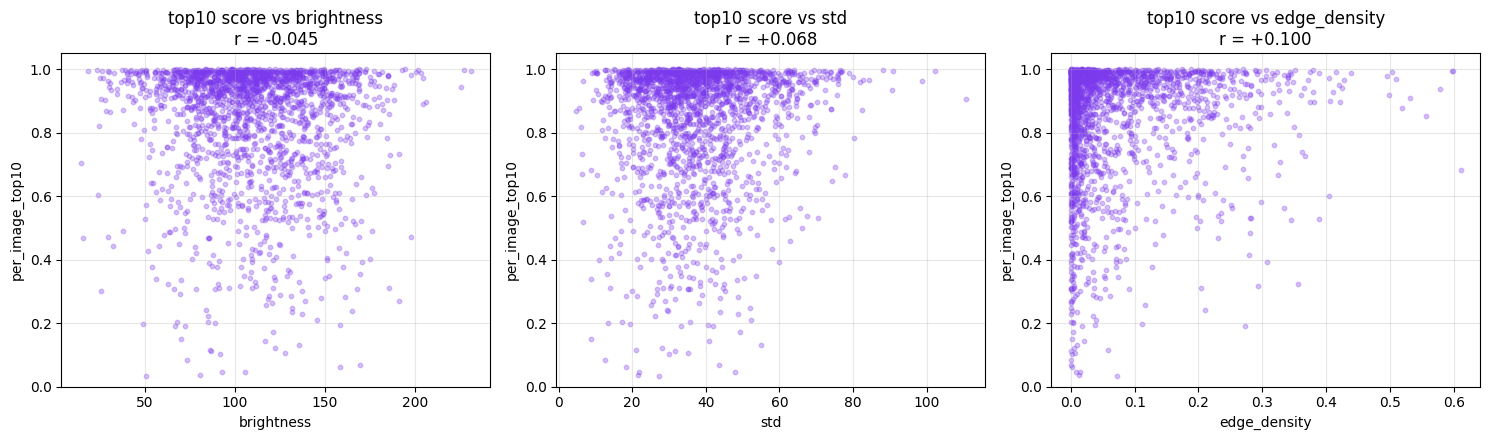

Combined data saved: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_scores_and_stats.csv


In [ ]:
# ============================================================
# Cell 10: Confound diagnostics (corrected)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats as scipy_stats
from tqdm.auto import tqdm

# --- 10.1 Compute image statistics for all 2000 fakes ----------
print('Computing image statistics for all 2,000 RSFAKE fakes...')

fake_dir = os.path.join(CROSS_ROOT, 'rsfake_subset', 'fake')
scores_df = pd.read_csv(os.path.join(CROSS_ROOT, 'rsfake_fake_per_image_scores.csv'))

stats_rows = []
for fname in tqdm(scores_df['filename'].values):
    path = os.path.join(fake_dir, fname)
    img = np.array(Image.open(path).convert('L'))  # grayscale

    brightness = float(img.mean())
    std_val    = float(img.std())

    # Edge density via absolute finite differences
    # np.diff along axis=1 → shape (H, W-1)
    # np.diff along axis=0 → shape (H-1, W)
    # Align both to shape (H-1, W-1) by trimming the right column from gx
    # and the bottom row from gy.
    gx = np.abs(np.diff(img.astype(np.int16), axis=1))[:-1, :]   # (H-1, W-1)
    gy = np.abs(np.diff(img.astype(np.int16), axis=0))[:, :-1]   # (H-1, W-1)
    edge_frac = float(((gx + gy) > 30).mean())

    stats_rows.append({
        'filename': fname,
        'brightness': brightness,
        'std': std_val,
        'edge_density': edge_frac,
    })

stats_df = pd.DataFrame(stats_rows)
combined = scores_df.merge(stats_df, on='filename')
print(f'Combined dataframe shape: {combined.shape}')

# --- 10.2 Compute correlations -------------------------------
print()
print('=' * 70)
print('CONFOUND ANALYSIS: per-image score vs image statistics')
print('=' * 70)
print(f'{"Statistic":<20s} {"vs mean":>12s} {"vs max":>12s} {"vs top10":>12s}')
print('-' * 70)

for stat_col in ['brightness', 'std', 'edge_density']:
    row = [stat_col]
    for score_col in ['per_image_mean', 'per_image_max', 'per_image_top10']:
        r, p = scipy_stats.pearsonr(combined[stat_col], combined[score_col])
        row.append(f'{r:+.3f}' + ('*' if p < 0.01 else ' '))
    print(f'{row[0]:<20s} {row[1]:>12s} {row[2]:>12s} {row[3]:>12s}')

print()
print('* p < 0.01')
print('|r| < 0.10: no meaningful correlation')
print('|r| 0.10 - 0.30: weak correlation')
print('|r| > 0.30: substantial — content confound suspected')

# --- 10.3 Visualise -----------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, stat_col in zip(axes, ['brightness', 'std', 'edge_density']):
    ax.scatter(combined[stat_col], combined['per_image_top10'],
               alpha=0.3, s=10, c='#7C3AED')
    r, _ = scipy_stats.pearsonr(combined[stat_col], combined['per_image_top10'])
    ax.set_xlabel(stat_col)
    ax.set_ylabel('per_image_top10')
    ax.set_title(f'top10 score vs {stat_col}\nr = {r:+.3f}')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(CROSS_ROOT, 'rsfake_confound_scatter.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'\nFigure saved: {fig_path}')
plt.show()

combined_csv = os.path.join(CROSS_ROOT, 'rsfake_scores_and_stats.csv')
combined.to_csv(combined_csv, index=False)
print(f'Combined data saved: {combined_csv}')

In [ ]:
# Quick recovery: re-download the SPLIT CSVs that ephemeral storage wiped
from huggingface_hub import hf_hub_download

for csv_name in ['RSFAKE_test_new.csv', 'RSFAKE_val_new.csv']:
    path = hf_hub_download(
        repo_id='TZHSW/RSFAKE',
        filename=f'SPLIT/{csv_name}',
        repo_type='dataset',
        local_dir='/content/rsfake_downloads',
    )
    print(f'  Restored: {path}')

# Now rerun Cell 11 from "--- 11.3 Filter ---" onwards,
# or just rerun the whole Cell 11 cell.

SPLIT/RSFAKE_test_new.csv:   0%|          | 0.00/12.6M [00:00<?, ?B/s]

  Restored: /content/rsfake_downloads/SPLIT/RSFAKE_test_new.csv


SPLIT/RSFAKE_val_new.csv:   0%|          | 0.00/13.5M [00:00<?, ?B/s]

  Restored: /content/rsfake_downloads/SPLIT/RSFAKE_val_new.csv


In [ ]:
import shutil
DRIVE_SPLIT_DIR = os.path.join(CROSS_ROOT, 'SPLIT')
os.makedirs(DRIVE_SPLIT_DIR, exist_ok=True)
for csv_name in ['RSFAKE_test_new.csv', 'RSFAKE_val_new.csv']:
    src = f'/content/rsfake_downloads/SPLIT/{csv_name}'
    dst = os.path.join(DRIVE_SPLIT_DIR, csv_name)
    if os.path.exists(src) and not os.path.exists(dst):
        shutil.copy2(src, dst)
        print(f'  Stashed: {dst}')

  Stashed: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/SPLIT/RSFAKE_test_new.csv
  Stashed: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/SPLIT/RSFAKE_val_new.csv


In [ ]:
# ============================================================
# Cell 11: Second cross-dataset test — generated_diffusion_sat
# Reuses everything from the rsinpaint run; only the source
# subset changes.
# ============================================================

import os
import zipfile
import random
import shutil
import pandas as pd
from huggingface_hub import hf_hub_download

# What we're testing this time
GENERATOR = 'diffusion_sat'   # short name for paths, logs
ZIP_FILENAME = f'FAKE/generated_{GENERATOR}.zip'

# Local download path (Colab fast disk)
LOCAL_DL = '/content/rsfake_downloads'

# Drive destination — separate folder per generator
DRIVE_FAKE_DIR = os.path.join(
    CROSS_ROOT, 'rsfake_subset', f'fake_{GENERATOR}'
)
os.makedirs(DRIVE_FAKE_DIR, exist_ok=True)

# --- 11.1 Download the zip --------------------------------
print(f'Downloading {ZIP_FILENAME} from HuggingFace...')
zip_path = hf_hub_download(
    repo_id=REPO_ID,
    filename=ZIP_FILENAME,
    repo_type='dataset',
    local_dir=LOCAL_DL,
)
size_mb = os.path.getsize(zip_path) / (1024**2)
print(f'  → {zip_path}  ({size_mb:,.1f} MB)')

# --- 11.2 Extract ----------------------------------------
EXTRACT_DIR = f'/content/rsfake_extracted_{GENERATOR}'
os.makedirs(EXTRACT_DIR, exist_ok=True)

print(f'\nExtracting...')
with zipfile.ZipFile(zip_path, 'r') as zf:
    zf.extractall(EXTRACT_DIR)

# The extracted folder is named after the generator
extracted_subdir = os.path.join(EXTRACT_DIR, f'generated_{GENERATOR}')
all_files = sorted(os.listdir(extracted_subdir))
print(f'Extracted {len(all_files):,} files')
print(f'Example filenames: {all_files[:3]}')

# Check what extensions are present
ext_counts = {}
for f in all_files:
    ext = f.rsplit('.', 1)[-1].lower() if '.' in f else 'no_ext'
    ext_counts[ext] = ext_counts.get(ext, 0) + 1
print(f'File extensions: {ext_counts}')

# --- 11.3 Filter to official test split, label=1 ---------
TEST_CSV = '/content/rsfake_downloads/SPLIT/RSFAKE_test_new.csv'
test_df = pd.read_csv(TEST_CSV)

# RSFAKE CSV uses 'dataset_name' to identify the generator
# Check what dataset_name value matches our generator
matching_names = test_df['dataset_name'].unique()
print(f'\nUnique dataset_name values in test CSV: {list(matching_names)}')

# DiffusionSat samples — find rows where dataset_name corresponds
# (We saw earlier that 'diffusionsat_256' and 'diffusionsat_512' both exist;
#  the diffusion_sat.zip likely maps to one of them. Inspect filenames to map.)
diffsat_test = test_df[
    test_df['dataset_name'].str.contains('diffusionsat', case=False, na=False)
    & (test_df['label'] == 1)
].copy()
print(f'\nTotal "diffusionsat" rows (label=1) in test: {len(diffsat_test):,}')
print(f'Breakdown by dataset_name:')
print(diffsat_test['dataset_name'].value_counts())

# Extract just the filename from the image_path
diffsat_test['filename'] = diffsat_test['image_path'].apply(
    lambda p: os.path.basename(p)
)

# Overlap check
extracted_set = set(all_files)
csv_filenames = set(diffsat_test['filename'])
overlap = extracted_set & csv_filenames
print(f'\nExtracted: {len(extracted_set):,}  CSV test rows: {len(csv_filenames):,}')
print(f'Overlap:   {len(overlap):,}')

if len(overlap) == 0:
    print('\n⚠️  Zero overlap — filename schemes differ. Will need to investigate.')
    print(f'  Example extracted: {all_files[0]}')
    print(f'  Example CSV:       {diffsat_test["image_path"].iloc[0]}')
else:
    # --- 11.4 Subsample 2000 (matching rsinpaint protocol) ---
    SUBSAMPLE_N = 2000
    RANDOM_SEED = 42

    random.seed(RANDOM_SEED)
    sample = random.sample(sorted(overlap), min(SUBSAMPLE_N, len(overlap)))
    print(f'\nSubsampled {len(sample)} test images (seed={RANDOM_SEED})')

    # --- 11.5 Copy to Drive -------------------------------
    print(f'\nCopying to {DRIVE_FAKE_DIR}...')
    for fname in sample:
        src = os.path.join(extracted_subdir, fname)
        dst = os.path.join(DRIVE_FAKE_DIR, fname)
        if not os.path.exists(dst):
            shutil.copy2(src, dst)

    drive_files = os.listdir(DRIVE_FAKE_DIR)
    total_mb = sum(
        os.path.getsize(os.path.join(DRIVE_FAKE_DIR, f)) for f in drive_files
    ) / (1024**2)
    print(f'Files on Drive: {len(drive_files):,}  ({total_mb:,.1f} MB)')

    # Save manifest
    manifest_path = os.path.join(
        CROSS_ROOT, f'rsfake_fake_{GENERATOR}_manifest.csv'
    )
    pd.DataFrame({'filename': sorted(sample)}).to_csv(manifest_path, index=False)
    print(f'Manifest: {manifest_path}')

  → /content/rsfake_downloads/FAKE/generated_diffusion_sat.zip  (2,001.7 MB)

Extracting...
Extracted 50,000 files
Example filenames: ['10076.jpg', '101023.jpg', '101026.jpg']
File extensions: {'jpg': 50000}

Unique dataset_name values in test CSV: ['fmow', 'crsdiff', 'diffusionsat_256', 'diffusionsat_512', 'georssd', 'geosynth_canny', 'geosynth_sam', 'geosynth_text', 'mapsat', 'rsinpaint', 'sdfrs']

Total "diffusionsat" rows (label=1) in test: 20,000
Breakdown by dataset_name:
dataset_name
diffusionsat_256    10000
diffusionsat_512    10000
Name: count, dtype: int64

Extracted: 50,000  CSV test rows: 20,000
Overlap:   10,000

Subsampled 2000 test images (seed=42)

Copying to /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_subset/fake_diffusion_sat...
Files on Drive: 2,000  (79.6 MB)
Manifest: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_fake_diffusion_sat_manifest.csv


In [ ]:
# ============================================================
# Cell 12: Extract DINOv2 features for 2,000 DiffusionSat fakes
# ============================================================

import os
import torch
import numpy as np
from PIL import Image
from tqdm.auto import tqdm

# This generator's specifics
GENERATOR     = 'diffusion_sat'
SRC_DIR       = os.path.join(CROSS_ROOT, 'rsfake_subset', f'fake_{GENERATOR}')
FEATURES_OUT  = os.path.join(CROSS_ROOT, f'rsfake_fake_{GENERATOR}_features.npz')

# List input files
fake_files = sorted(os.listdir(SRC_DIR))
fake_paths = [os.path.join(SRC_DIR, f) for f in fake_files]
print(f'Images to process: {len(fake_paths):,}')
print(f'Output: {FEATURES_OUT}')

# --- 12.1 Extraction loop -------------------------------------
all_features = []
all_image_ids = []
failed = []

BATCH_SIZE = 32

print('\nExtracting DINOv2 patch features...')
with torch.no_grad():
    for batch_start in tqdm(range(0, len(fake_paths), BATCH_SIZE)):
        batch_paths = fake_paths[batch_start:batch_start + BATCH_SIZE]
        batch_tensors = []
        batch_ids = []

        for i, path in enumerate(batch_paths):
            try:
                img = Image.open(path).convert('RGB')
                tensor = preprocess(img)
                batch_tensors.append(tensor)
                batch_ids.append(batch_start + i)
            except Exception as e:
                failed.append((path, str(e)))

        if not batch_tensors:
            continue

        batch = torch.stack(batch_tensors).to(device)
        out = dinov2.forward_features(batch)
        patch_features = out['x_norm_patchtokens'].cpu().numpy()

        for i, img_idx in enumerate(batch_ids):
            all_features.append(patch_features[i])      # (256, 768)
            all_image_ids.append(np.full(256, img_idx, dtype=np.int64))

# Stack
features_array = np.concatenate(all_features, axis=0)        # (2000*256, 768)
image_ids_array = np.concatenate(all_image_ids, axis=0)      # (2000*256,)

print(f'\nFeatures shape: {features_array.shape}')
print(f'Image IDs shape: {image_ids_array.shape}')
print(f'Unique images: {len(np.unique(image_ids_array))}')
print(f'Failed loads: {len(failed)}')
if failed:
    print('First 3 failures:')
    for path, err in failed[:3]:
        print(f'  {path}: {err}')

# --- 12.2 Save ------------------------------------------------
filenames_array = np.array([fake_files[i] for i in np.unique(image_ids_array)])

np.savez_compressed(
    FEATURES_OUT,
    features=features_array,
    image_ids=image_ids_array,
    filenames=filenames_array,
)

size_mb = os.path.getsize(FEATURES_OUT) / (1024**2)
print(f'\nSaved: {FEATURES_OUT}  ({size_mb:,.1f} MB)')

Images to process: 2,000
Output: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_fake_diffusion_sat_features.npz

Extracting DINOv2 patch features...


  0%|          | 0/63 [00:00<?, ?it/s]


Features shape: (512000, 768)
Image IDs shape: (512000,)
Unique images: 2000
Failed loads: 0

Saved: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_fake_diffusion_sat_features.npz  (1,394.0 MB)


In [ ]:
# ============================================================
# Cell 13: Apply probe to DiffusionSat features,
# compare side-by-side with rsinpaint results
# ============================================================

import os
import numpy as np
import pandas as pd

GENERATOR = 'diffusion_sat'
FAKE_FEATURES_PATH = os.path.join(CROSS_ROOT, f'rsfake_fake_{GENERATOR}_features.npz')

# --- 13.1 Load DiffusionSat features ----------------------------
print('Loading DiffusionSat features...')
with np.load(FAKE_FEATURES_PATH) as data:
    X_diffsat = data['features']
    image_ids_diffsat = data['image_ids']
    filenames_diffsat = data['filenames']

print(f'  Features: {X_diffsat.shape}')

# --- 13.2 Apply scaler then probe -----------------------------
print('\nApplying scaler and probe to 512,000 patches...')
X_diffsat_scaled = scaler.transform(X_diffsat)
probs_patch_diffsat = probe.predict_proba(X_diffsat_scaled)[:, 1]

# --- 13.3 Aggregate to per-image scores -----------------------
unique_ids = np.unique(image_ids_diffsat)
n_images = len(unique_ids)

per_image_mean  = np.zeros(n_images)
per_image_max   = np.zeros(n_images)
per_image_top10 = np.zeros(n_images)

for i, img_id in enumerate(unique_ids):
    mask = image_ids_diffsat == img_id
    patch_probs = probs_patch_diffsat[mask]
    per_image_mean[i]  = patch_probs.mean()
    per_image_max[i]   = patch_probs.max()
    per_image_top10[i] = np.sort(patch_probs)[-10:].mean()

# --- 13.4 Save per-image scores ------------------------------
scores_df = pd.DataFrame({
    'filename': [filenames_diffsat[i] for i in range(n_images)],
    'per_image_mean': per_image_mean,
    'per_image_max': per_image_max,
    'per_image_top10': per_image_top10,
})
scores_csv = os.path.join(CROSS_ROOT, f'rsfake_fake_{GENERATOR}_per_image_scores.csv')
scores_df.to_csv(scores_csv, index=False)
print(f'Per-image scores saved: {scores_csv}')

# --- 13.5 Side-by-side comparison with rsinpaint -------------
# Load rsinpaint scores for direct comparison
# Re-print the comparison table with a working formatter
# Uses variables already in memory from Cell 13

rsinpaint_scores = pd.read_csv(
    os.path.join(CROSS_ROOT, 'rsfake_fake_per_image_scores.csv')
)

print('=' * 78)
print('CROSS-GENERATOR COMPARISON')
print('=' * 78)
print('Both n=2,000 official test images. Same DINOv2 + linear probe.')
print()
print(f'{"Aggregation":<24s} | {"rsinpaint":>12s} | {"diffusion_sat":>15s}')
print(f'{"":<24s} | {"(inpainting)":>12s} | {"(whole-image)":>15s}')
print('-' * 78)

def print_section(title, rsv_arr, dsv_arr):
    print(f'\n  {title}')
    print(f'  {"Mean":<22s} | {rsv_arr.mean():>12.4f} | {dsv_arr.mean():>15.4f}')
    print(f'  {"Median":<22s} | {np.median(rsv_arr):>12.4f} | {np.median(dsv_arr):>15.4f}')
    pct_05_rs = (rsv_arr > 0.5).mean() * 100
    pct_05_ds = (dsv_arr > 0.5).mean() * 100
    pct_07_rs = (rsv_arr > 0.7).mean() * 100
    pct_07_ds = (dsv_arr > 0.7).mean() * 100
    print(f'  {"% above 0.5":<22s} | {pct_05_rs:>11.1f}% | {pct_05_ds:>14.1f}%')
    print(f'  {"% above 0.7":<22s} | {pct_07_rs:>11.1f}% | {pct_07_ds:>14.1f}%')

print_section('Per-patch mean',
              rsinpaint_scores['per_image_mean'].values, per_image_mean)
print_section('Per-patch max',
              rsinpaint_scores['per_image_max'].values, per_image_max)
print_section('Top-10 mean',
              rsinpaint_scores['per_image_top10'].values, per_image_top10)

print()
print('=' * 78)

Loading DiffusionSat features...
  Features: (512000, 768)

Applying scaler and probe to 512,000 patches...
Per-image scores saved: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_fake_diffusion_sat_per_image_scores.csv
CROSS-GENERATOR COMPARISON
Both n=2,000 official test images. Same DINOv2 + linear probe.

Aggregation              |    rsinpaint |   diffusion_sat
                         | (inpainting) |   (whole-image)
------------------------------------------------------------------------------

  Per-patch mean
  Mean                   |       0.1941 |          0.2125
  Median                 |       0.1682 |          0.2004
  % above 0.5            |         3.1% |            1.5%
  % above 0.7            |         0.3% |            0.1%

  Per-patch max
  Mean                   |       0.9430 |          0.9510
  Median                 |       0.9860 |          0.9815
  % above 0.5            |        98.6% |           99.2%
  % above 0.7            |        95

In [ ]:
# ============================================================
# Cell 14: Qualitative check — DiffusionSat heatmaps
# Mirrors Cell 9's protocol so the two figures are directly
# comparable: 3 high-confidence, 2 mid-confidence, 1 low.
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import torch

GENERATOR = 'diffusion_sat'
SRC_DIR   = os.path.join(CROSS_ROOT, 'rsfake_subset', f'fake_{GENERATOR}')
SCORES_CSV = os.path.join(CROSS_ROOT, f'rsfake_fake_{GENERATOR}_per_image_scores.csv')

scores_df = pd.read_csv(SCORES_CSV)
print(f'Loaded scores for {len(scores_df)} images')

# --- 14.1 Stratified sample selection ------------------------
# Same strategy as Cell 9: pick across the confidence spectrum
high_conf = scores_df[scores_df['per_image_max'] > 0.95].sample(3, random_state=42)
mid_conf  = scores_df[
    (scores_df['per_image_max'] > 0.5) & (scores_df['per_image_max'] < 0.8)
].sample(2, random_state=42)

low_pool = scores_df[scores_df['per_image_max'] < 0.3]
if len(low_pool) > 0:
    low_conf = low_pool.sample(min(1, len(low_pool)), random_state=42)
else:
    # If no scores below 0.3, take the lowest-scoring sample
    low_conf = scores_df.nsmallest(1, 'per_image_max')

samples = pd.concat([high_conf, mid_conf, low_conf]).reset_index(drop=True)
print(f'\nSelected {len(samples)} samples spanning confidence range:')
for _, row in samples.iterrows():
    print(f"  {row['filename']}: max={row['per_image_max']:.3f}, "
          f"top10={row['per_image_top10']:.3f}, mean={row['per_image_mean']:.3f}")

# --- 14.2 Recompute patch probs for the selected samples ----
print('\nExtracting features and computing heatmaps for selected samples...')
sample_data = []

with torch.no_grad():
    for _, row in samples.iterrows():
        fname = row['filename']
        path = os.path.join(SRC_DIR, fname)

        img_original = Image.open(path).convert('RGB')
        tensor = preprocess(img_original).unsqueeze(0).to(device)
        out = dinov2.forward_features(tensor)
        patch_feats = out['x_norm_patchtokens'].cpu().numpy()[0]    # (256, 768)

        patch_feats_scaled = scaler.transform(patch_feats)
        patch_probs = probe.predict_proba(patch_feats_scaled)[:, 1]  # (256,)
        heatmap = patch_probs.reshape(16, 16)

        sample_data.append({
            'filename': fname,
            'image': img_original,
            'heatmap': heatmap,
            'max_score': row['per_image_max'],
            'top10_score': row['per_image_top10'],
            'mean_score': row['per_image_mean'],
        })

# --- 14.3 Render figure ------------------------------------
n = len(sample_data)
fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

for i, sd in enumerate(sample_data):
    img_resized = sd['image'].resize((224, 224))
    img_array = np.array(img_resized)

    # Col 1: original (resized to 224 for comparable display)
    axes[i, 0].imshow(img_array)
    axes[i, 0].set_title(
        f'{sd["filename"]}\n'
        f'max={sd["max_score"]:.3f}, top10={sd["top10_score"]:.3f}, '
        f'mean={sd["mean_score"]:.3f}',
        fontsize=10,
    )
    axes[i, 0].axis('off')

    # Col 2: heatmap alone
    axes[i, 1].imshow(sd['heatmap'], cmap='hot', vmin=0, vmax=1,
                      extent=[0, 224, 224, 0])
    axes[i, 1].set_title('Predicted P(manipulated) per patch', fontsize=10)
    axes[i, 1].axis('off')

    # Col 3: overlay
    axes[i, 2].imshow(img_array)
    heatmap_upsampled = np.kron(sd['heatmap'], np.ones((14, 14)))
    axes[i, 2].imshow(heatmap_upsampled, cmap='hot', alpha=0.5, vmin=0, vmax=1)
    axes[i, 2].set_title('Overlay', fontsize=10)
    axes[i, 2].axis('off')

plt.suptitle(
    f'DiffusionSat (whole-image generation) — n=2,000 RSFAKE test samples',
    fontsize=12, y=1.001,
)
plt.tight_layout()

figure_path = os.path.join(CROSS_ROOT, f'rsfake_heatmaps_{GENERATOR}_qualitative.png')
plt.savefig(figure_path, dpi=120, bbox_inches='tight')
print(f'\nFigure saved: {figure_path}')
plt.show()

Output hidden; open in https://colab.research.google.com to view.

Computing image statistics for 2,000 diffusion_sat fakes...


  0%|          | 0/2000 [00:00<?, ?it/s]

Combined dataframe shape: (2000, 7)

CONFOUND ANALYSIS — diffusion_sat
Statistic                 vs mean       vs max     vs top10
----------------------------------------------------------------------
brightness                -0.201*      -0.046       -0.101*
std                       +0.053       +0.025       +0.035 
edge_density              +0.019       -0.048       -0.048 

CONFOUND COMPARISON: rsinpaint vs diffusion_sat

Statistic       Score                 rsinpaint   diffusion_sat          Δ
----------------------------------------------------------------------------
brightness      per_image_mean           -0.089          -0.201     -0.112
brightness      per_image_max            -0.019          -0.046     -0.027
brightness      per_image_top10          -0.045          -0.101     -0.056
std             per_image_mean           +0.073          +0.053     -0.020
std             per_image_max            +0.067          +0.025     -0.042
std             per_image_top10          

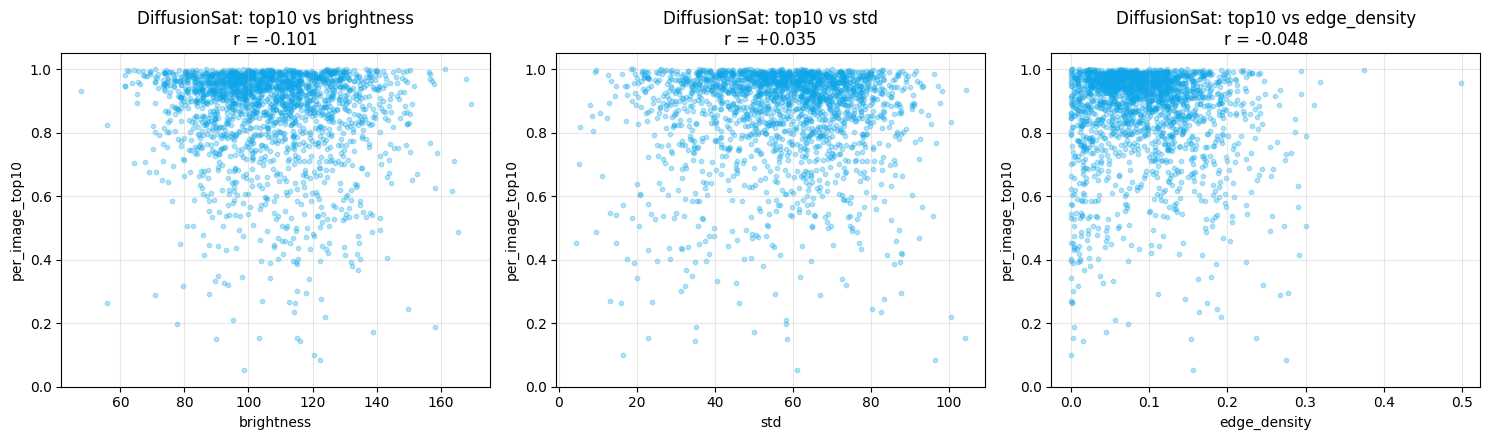

Combined data saved: /content/drive/MyDrive/Satforensics_dataset/cross_dataset/rsfake_scores_and_stats_diffusion_sat.csv


In [ ]:
  # ============================================================
# Cell 15: Confound diagnostics on DiffusionSat (mirrors Cell 10
# protocol for rsinpaint, so the two are directly comparable)
# ============================================================

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import stats as scipy_stats
from tqdm.auto import tqdm

GENERATOR  = 'diffusion_sat'
SRC_DIR    = os.path.join(CROSS_ROOT, 'rsfake_subset', f'fake_{GENERATOR}')
SCORES_CSV = os.path.join(CROSS_ROOT, f'rsfake_fake_{GENERATOR}_per_image_scores.csv')

scores_df = pd.read_csv(SCORES_CSV)
print(f'Computing image statistics for {len(scores_df):,} {GENERATOR} fakes...')

# --- 15.1 Compute image statistics --------------------------
stats_rows = []
for fname in tqdm(scores_df['filename'].values):
    path = os.path.join(SRC_DIR, fname)
    img = np.array(Image.open(path).convert('L'))

    brightness = float(img.mean())
    std_val    = float(img.std())

    # Edge density (same fix as Cell 10)
    gx = np.abs(np.diff(img.astype(np.int16), axis=1))[:-1, :]
    gy = np.abs(np.diff(img.astype(np.int16), axis=0))[:, :-1]
    edge_frac = float(((gx + gy) > 30).mean())

    stats_rows.append({
        'filename': fname,
        'brightness': brightness,
        'std': std_val,
        'edge_density': edge_frac,
    })

stats_df = pd.DataFrame(stats_rows)
combined_diffsat = scores_df.merge(stats_df, on='filename')
print(f'Combined dataframe shape: {combined_diffsat.shape}')

# --- 15.2 Compute correlations -------------------------------
print()
print('=' * 70)
print(f'CONFOUND ANALYSIS — {GENERATOR}')
print('=' * 70)
print(f'{"Statistic":<20s} {"vs mean":>12s} {"vs max":>12s} {"vs top10":>12s}')
print('-' * 70)

diffsat_results = {}
for stat_col in ['brightness', 'std', 'edge_density']:
    diffsat_results[stat_col] = {}
    row = [stat_col]
    for score_col in ['per_image_mean', 'per_image_max', 'per_image_top10']:
        r, p = scipy_stats.pearsonr(combined_diffsat[stat_col], combined_diffsat[score_col])
        diffsat_results[stat_col][score_col] = r
        row.append(f'{r:+.3f}' + ('*' if p < 0.01 else ' '))
    print(f'{row[0]:<20s} {row[1]:>12s} {row[2]:>12s} {row[3]:>12s}')

# --- 15.3 Side-by-side comparison with rsinpaint ------------
print()
print('=' * 76)
print('CONFOUND COMPARISON: rsinpaint vs diffusion_sat')
print('=' * 76)

# Load rsinpaint combined stats
rsinpaint_combined = pd.read_csv(
    os.path.join(CROSS_ROOT, 'rsfake_scores_and_stats.csv')
)

print(f'\n{"Statistic":<15s} {"Score":<18s} {"rsinpaint":>12s} {"diffusion_sat":>15s} {"Δ":>10s}')
print('-' * 76)

for stat_col in ['brightness', 'std', 'edge_density']:
    for score_col in ['per_image_mean', 'per_image_max', 'per_image_top10']:
        r_rs, _ = scipy_stats.pearsonr(
            rsinpaint_combined[stat_col], rsinpaint_combined[score_col]
        )
        r_ds = diffsat_results[stat_col][score_col]
        delta = r_ds - r_rs
        print(f'{stat_col:<15s} {score_col:<18s} {r_rs:>+12.3f} {r_ds:>+15.3f} {delta:>+10.3f}')

print()
print('* p < 0.01 (n=2000 has high power, so even tiny correlations test significant)')
print('Interpretation: |r| < 0.10 = no confound, 0.10–0.30 = weak, > 0.30 = substantial')

# --- 15.4 Visualise --------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

for ax, stat_col in zip(axes, ['brightness', 'std', 'edge_density']):
    ax.scatter(combined_diffsat[stat_col], combined_diffsat['per_image_top10'],
               alpha=0.3, s=10, c='#0EA5E9')   # cyan to distinguish from rsinpaint purple
    r, _ = scipy_stats.pearsonr(
        combined_diffsat[stat_col], combined_diffsat['per_image_top10']
    )
    ax.set_xlabel(stat_col)
    ax.set_ylabel('per_image_top10')
    ax.set_title(f'DiffusionSat: top10 vs {stat_col}\nr = {r:+.3f}')
    ax.set_ylim(0, 1.05)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(CROSS_ROOT, f'rsfake_confound_scatter_{GENERATOR}.png')
plt.savefig(fig_path, dpi=120, bbox_inches='tight')
print(f'\nFigure saved: {fig_path}')
plt.show()

# Save the combined dataframe
combined_csv = os.path.join(CROSS_ROOT, f'rsfake_scores_and_stats_{GENERATOR}.csv')
combined_diffsat.to_csv(combined_csv, index=False)
print(f'Combined data saved: {combined_csv}')

In [11]:
model_card = """---
license: other
license_name: research-use-only
language:
- en
tags:
- satellite-imagery
- forensics
- forgery-detection
- dinov2
- linear-probe
- remote-sensing
---

# SatForensics: DINOv2 + Linear Probe for Satellite Image Manipulation Detection

This repository contains the trained linear probe, feature scaler, and cached features
for the SatForensics project — an MSc dissertation project at Newcastle University
exploring foundation models as forensic priors for detecting AI-generated manipulations
in satellite imagery.

## What's in this repo

### `models/`
- `dinov2_linear_probe.pkl` — Trained scikit-learn LogisticRegression
- `dinov2_feature_scaler.pkl` — Fitted StandardScaler (apply BEFORE the probe)

### `features/`
- `dinov2_features.npz` — Cached DINOv2 features for the training/test set
  - `features`: shape `(468480, 768)`, float32 (1,830 images × 256 patches)
  - `labels`: shape `(468480,)`, int64 (0 = authentic, 1 = manipulated)
  - `image_ids`: shape `(468480,)`, int64 (maps each patch to its source image)

### `results/`
- `rsfake_fake_per_image_scores.csv` — Per-image scores on RSFAKE-1M rsinpaint (n=2000)
- `rsfake_fake_diffusion_sat_per_image_scores.csv` — Same for DiffusionSat (n=2000)
- `rsfake_scores_and_stats*.csv` — Scores joined with brightness/std/edge_density stats
- `rsfake_heatmaps_*_qualitative.png` — 6-sample heatmap visualisations
- `rsfake_confound_scatter_*.png` — Score vs image-statistics scatter plots

## Training setup

- **Backbone**: DINOv2-Base ViT (`facebookresearch/dinov2_vitb14`), frozen
- **Input preprocessing**: Resize to 224×224 (bicubic), ImageNet normalisation
- **Patch grid**: 16×16 = 256 patches per image (14px patches)
- **Training data**: Airbus satellite imagery + CLIP-guided Stable Diffusion 2 +
  ControlNet inpainting (Chapman et al. 2025 pipeline)
- **Split**: by-image, seed=42, 70/15/15 → 1,281 train / 274 val / 275 test
- **Probe**: scikit-learn LogisticRegression
  - `class_weight='balanced'`, `solver='lbfgs'`, `max_iter=1000`, `random_state=42`

## Headline results

| Metric | Value |
|---|---|
| Pooled test patch AUROC (Airbus, n=70,400 test patches) | **0.9593** |
| RSFAKE rsinpaint top-10 mean (n=2,000) | 0.84 |
| RSFAKE rsinpaint % above 0.7 (max) | 95.7% |
| RSFAKE DiffusionSat top-10 mean (n=2,000) | 0.86 |
| RSFAKE DiffusionSat % above 0.7 (max) | 97.2% |
| Confound checks (brightness/std/edge_density) | All \\|r\\| ≤ 0.21 |

## Related work

- **Chapman et al. (2025)** — Geospatially-Aware Multi-Modal Fusion for Satellite Image
  Manipulation Detection. VCIP 2025.
- **Oquab et al. (2023)** — DINOv2: Learning Robust Visual Features without Supervision.
  arXiv:2304.07193.

## Project

This work is part of an MSc dissertation at Newcastle University (Project 22:
SatForensics), supervised by Dr. Deepayan Bhowmik.

The cross-dataset evaluation notebook is at:
https://github.com/Om-Ravindra-Patil/satforensics-crossdataset

## License

The trained probe and cached features are released for research use only.
The underlying training imagery is licensed separately by Airbus.
"""

# Write the markdown to a temporary file on Colab's local disk
with open('/tmp/README.md', 'w') as f:
    f.write(model_card)

# Upload that file to HuggingFace as the repo's README
api.upload_file(
    path_or_fileobj='/tmp/README.md',
    path_in_repo='README.md',
    repo_id='OmPatil9819/satforensics-dinov2-probe',
    repo_type='model',
    token=token,
)
print('Model card uploaded')
print('Visit: https://huggingface.co/OmPatil9819/satforensics-dinov2-probe')

✓ Model card uploaded
Visit: https://huggingface.co/OmPatil9819/satforensics-dinov2-probe


In [15]:
# ============================================================
# Push notebook + README to GitHub (notebook source fixed)
# ============================================================
import os, shutil
from google.colab import userdata

# --- 6.1 Prepare a clean working directory --------------
REPO_DIR = '/content/github_satforensics'
!rm -rf {REPO_DIR}
!mkdir -p {REPO_DIR}

%cd {REPO_DIR}

# --- 6.2 Copy notebook from its actual location ---------
NOTEBOOK_SRC = '/content/drive/MyDrive/Colab Notebooks/SatForensics_CrossDataset.ipynb'
NOTEBOOK_DST = 'SatForensics_CrossDataset.ipynb'

assert os.path.exists(NOTEBOOK_SRC), f'Notebook not found: {NOTEBOOK_SRC}'
shutil.copy(NOTEBOOK_SRC, NOTEBOOK_DST)
print(f'✓ Copied notebook from {NOTEBOOK_SRC}')

# --- 6.3 Write the README -------------------------------
readme = """# SatForensics — Cross-Dataset Evaluation

Cross-dataset evaluation of a frozen DINOv2 + linear probe for satellite image
manipulation detection. Part of an MSc dissertation at Newcastle University
(Project 22), supervised by Dr. Deepayan Bhowmik.

## What this repo contains

- `SatForensics_CrossDataset.ipynb` — The evaluation notebook covering:
  - RSFAKE-1M download and filtering to the official test split
  - DINOv2 feature extraction on subsampled fakes
  - Probe application and per-image score aggregation
  - Stratified heatmap visualisation
  - Confound diagnostics (brightness, std, edge density)

## Where the model lives

The trained linear probe, feature scaler, and cached features are hosted on
HuggingFace:

https://huggingface.co/OmPatil9819/satforensics-dinov2-probe

## Headline result

Pooled test patch AUROC on the Airbus validation set: **0.9593**
(See the HF model card for cross-dataset numbers.)

## Running the notebook

The notebook expects to run in Google Colab with:
- A GPU (A100 recommended; T4 also works for 2000-image subsets)
- Google Drive mounted for persistent storage
- A HuggingFace token in Colab Secrets (named `HF_TOKEN`) for dataset access

The first cell (Bootstrap) handles environment setup. After that, cells run
sequentially.

## Datasets used

- **Training**: Airbus satellite imagery + CLIP-guided SD2 + ControlNet inpainting
  (from Chapman et al. 2025, VCIP)
- **Cross-dataset evaluation**: RSFAKE-1M (Tan et al. 2025, arXiv:2505.23283)
  hosted at `huggingface.co/datasets/TZHSW/RSFAKE`

## Citation context

If using this code or the model, please cite the upstream:
- **DINOv2**: Oquab et al. (2023), arXiv:2304.07193
- **RSFAKE-1M**: Tan et al. (2025), arXiv:2505.23283
- **Chapman et al. (2025)**, VCIP — provided the training data pipeline

## Author

Om Ravindra Patil — MSc Data Science, Newcastle University, 2026.
"""

with open('README.md', 'w') as f:
    f.write(readme)
print('✓ README.md written')

# --- 6.4 Write requirements.txt -------------------------
requirements = """# Core ML
torch
torchvision
scikit-learn>=1.3
joblib

# Data
numpy
pandas
scipy

# Image / plotting
Pillow
matplotlib

# HuggingFace ecosystem
huggingface_hub>=0.20
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements)
print('✓ requirements.txt written')

print('\nFiles ready in', REPO_DIR)
!ls -lh

# --- 6.5 Git init and push -------------------------------
GITHUB_USER = 'Om-Ravindra-Patil'
GITHUB_REPO = 'satforensics-crossdataset'
GITHUB_PAT = userdata.get('GITHUB_PAT')

!git config --global user.email "O.R.Patil2@newcastle.ac.uk"
!git config --global user.name "Om Ravindra Patil"

!git init -q
!git checkout -b main 2>/dev/null
!git add .
!git commit -q -m "Initial commit: cross-dataset evaluation notebook + README"

remote_url = f'https://{GITHUB_PAT}@github.com/{GITHUB_USER}/{GITHUB_REPO}.git'
!git remote add origin {remote_url}
!git push -u origin main

print(f'\n✓ Pushed to https://github.com/{GITHUB_USER}/{GITHUB_REPO}')

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
/content/github_satforensics
✓ Copied notebook from /content/drive/MyDrive/Colab Notebooks/SatForensics_CrossDataset.ipynb
✓ README.md written
✓ requirements.txt written

Files ready in /content/github_satforensics
total 840K
-rw-r--r-- 1 root root 1.9K Jun 19 21:29 README.md
-rw-r--r-- 1 root root  165 Jun 19 21:29 requirements.txt
-rw------- 1 root root 832K Jun 19 21:29 SatForensics_CrossDataset.ipynb


SecretNotFoundError: Secret GITHUB_PAT does not exist.